In [1]:
import sys
import pandas as pd
from pathlib import Path
import logging
pd.__version__

'3.0.0'

In [2]:


Base_Dir = Path.cwd().resolve()
data_dir = Base_Dir / "loans_data1.csv"
log_dir = Base_Dir / "logs"
log_dir.mkdir(exist_ok=True)
log_file = log_dir / "app.log"

loger = logging.getLogger(__name__)
loger.setLevel(logging.INFO)
if not loger.handlers:
    loger.handlers.clear()
    h = logging.StreamHandler(sys.stdout)
    h.setFormatter(logging.Formatter("%(asctime)s - %(levelname)s - %(message)s"))
    loger.addHandler(h)

    hf = logging.FileHandler(log_file)
    hf.setFormatter(logging.Formatter("%(asctime)s - %(levelname)s - %(message)s"))
    loger.addHandler(hf)
    loger.propagate = False
    
loger.info(f"Base Directory: {Base_Dir}")

loans_df = pd.read_csv(data_dir)
loans_df.shape


2026-02-22 21:31:04,958 - INFO - Base Directory: /Users/qiyunge/winMac/SoftwareDev/LaselleCollege/data_science/data_eda


(2500, 15)

In [3]:
loans_df.head(10)

,ID,Amount.Requested,Amount.Funded.By.Investors,Interest.Rate,Loan.Length,Loan.Purpose,Debt.To.Income.Ratio,State,Home.Ownership,Monthly.Income,FICO.Range,Open.CREDIT.Lines,Revolving.CREDIT.Balance,Inquiries.in.the.Last.6.Months,Employment.Length
0,81174.0,20000,20000,8.90%,36 months,debt_consolidation,14.90%,SC,MORTGAGE,6541.67,735-739,14,14272,2.0,< 1 year
1,99592.0,19200,19200,12.12%,36 months,debt_consolidation,28.36%,TX,MORTGAGE,4583.33,715-719,12,11140,1.0,2 years
2,80059.0,35000,35000,21.98%,60 months,debt_consolidation,23.81%,CA,MORTGAGE,11500.00,690-694,14,21977,1.0,2 years
3,15825.0,10000,9975,9.99%,36 months,debt_consolidation,14.30%,KS,MORTGAGE,3833.33,695-699,10,9346,0.0,5 years
4,33182.0,12000,12000,11.71%,36 months,credit_card,18.78%,NJ,RENT,3195.00,695-699,11,14469,0.0,9 years
5,62403.0,6000,6000,15.31%,36 months,other,20.05%,CT,OWN,4891.67,670-674,17,10391,2.0,3 years
6,48808.0,10000,10000,7.90%,36 months,debt_consolidation,26.09%,MA,RENT,2916.67,720-724,10,15957,0.0,10+ years
7,22090.0,33500,33450,17.14%,60 months,credit_card,14.70%,LA,MORTGAGE,13863.42,705-709,12,27874,0.0,10+ years
8,76404.0,14675,14675,14.33%,36 months,credit_card,26.92%,CA,RENT,3150.00,685-689,9,7246,1.0,8 years
9,15867.0,.,7000,6.91%,36 months,credit_card,7.10%,CA,RENT,5000.00,715-719,8,7612,0.0,3 years


In [4]:
#step 1:data typing/schema cleaning
loans_df.info()
# loans_df.describe()
# loans_df.shape
# loans_df.columns
# loans_df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              2499 non-null   float64
 1   Amount.Requested                2499 non-null   str    
 2   Amount.Funded.By.Investors      2499 non-null   str    
 3   Interest.Rate                   2500 non-null   str    
 4   Loan.Length                     2499 non-null   str    
 5   Loan.Purpose                    2499 non-null   str    
 6   Debt.To.Income.Ratio            2499 non-null   str    
 7   State                           2499 non-null   str    
 8   Home.Ownership                  2499 non-null   str    
 9   Monthly.Income                  2497 non-null   float64
 10  FICO.Range                      2500 non-null   str    
 11  Open.CREDIT.Lines               2496 non-null   str    
 12  Revolving.CREDIT.Balance        2497 non-null

In [5]:
loans_df["Interest.Rate"] = loans_df["Interest.Rate"].astype("string").str.strip("%")
loans_df["Loan.Months"] = loans_df["Loan.Length"].astype("string").str.extract(r"(\d+)", expand=False)
loans_df["Debt.To.Income.Ratio"] = loans_df["Debt.To.Income.Ratio"].astype("string").str.strip("%")
loans_df[["Fico.Range.Low","Fico.Range.High"]] = loans_df["FICO.Range"].astype("string").str.split("-",expand=True)

loans_df = loans_df.drop(columns=["FICO.Range", "FICO.Range","Loan.Length"], inplace=False)


# loans_df[["FICO.Range","Fico.Range.Low","Fico.Range.High"]].head()
cols_numeric = [
    "Amount.Requested",
    "Amount.Funded.By.Investors",
    "Interest.Rate",
    "Debt.To.Income.Ratio",
    "Monthly.Income",
    "Fico.Range.Low",
    "Fico.Range.High",
    "Open.CREDIT.Lines",
    "Revolving.CREDIT.Balance",
    "Inquiries.in.the.Last.6.Months"
]

cols_categorical = [
    "Employment.Length",
    "Loan.Purpose",
    "State",
    "Home.Ownership",
    "Loan.Months",
]

loans_df[cols_numeric] = loans_df[cols_numeric].apply(lambda x: pd.to_numeric(x, errors="coerce"))
loans_df = loans_df[~loans_df.isna().any(axis=1)]

n = 0
for col in cols_numeric:
        print(f"{n}:{col} - type: numeric")
        n += 1
for col in cols_categorical:
        print(f"{n}:{col} - type: categorical")
        n += 1

# loans_df.astype({"ID":"string",
#                  "Amount.Requested":"Float64",
#                  "Amount.Funded.By.Investors":"Float64",
#                  "Interest.Rate":"Float64",
#                  "Debt.To.Income.Ratio":"Float64",
#                  "Loan.Months":"Int64",
#                  "Monthly.Income":"Float64",
#               #   "FICO.Range":"Int64",
#                 "Fico.Range.Low":"Int64",
#                 "Fico.Range.High":"Int64",
#                  "Open.CREDIT.Lines":"Int64",
#                  "Revolving.CREDIT.Balance":"Float64",
#                  "Inquiries.in.the.Last.6.Months":"Int64",
#                  "Employment.Length":"string",
#                  "Loan.Purpose":"string",
#                  "State":"string",
#                  "Home.Ownership":"string",
# })


0:Amount.Requested - type: numeric
1:Amount.Funded.By.Investors - type: numeric
2:Interest.Rate - type: numeric
3:Debt.To.Income.Ratio - type: numeric
4:Monthly.Income - type: numeric
5:Fico.Range.Low - type: numeric
6:Fico.Range.High - type: numeric
7:Open.CREDIT.Lines - type: numeric
8:Revolving.CREDIT.Balance - type: numeric
9:Inquiries.in.the.Last.6.Months - type: numeric
10:Employment.Length - type: categorical
11:Loan.Purpose - type: categorical
12:State - type: categorical
13:Home.Ownership - type: categorical
14:Loan.Months - type: categorical


In [6]:
loans_df.duplicated().sum()

np.int64(0)

In [7]:
#step 2: missing value handling
loans_df.isnull().sum()/loans_df.shape[0]*100

ID                                0.0
Amount.Requested                  0.0
Amount.Funded.By.Investors        0.0
Interest.Rate                     0.0
Loan.Purpose                      0.0
Debt.To.Income.Ratio              0.0
State                             0.0
Home.Ownership                    0.0
Monthly.Income                    0.0
Open.CREDIT.Lines                 0.0
Revolving.CREDIT.Balance          0.0
Inquiries.in.the.Last.6.Months    0.0
Employment.Length                 0.0
Loan.Months                       0.0
Fico.Range.Low                    0.0
Fico.Range.High                   0.0
dtype: float64

In [8]:
loans_df[cols_numeric].describe()

,Amount.Requested,Amount.Funded.By.Investors,Interest.Rate,Debt.To.Income.Ratio,Monthly.Income,Fico.Range.Low,Fico.Range.High,Open.CREDIT.Lines,Revolving.CREDIT.Balance,Inquiries.in.the.Last.6.Months
count,2393.000000,2393.000000,2393.0,2393.0,2393.000000,2393.0,2393.0,2393.000000,2393.000000,2393.000000
mean,12524.770163,12104.003188,13.087234,15.395186,5742.625178,705.785625,709.785625,10.126619,15363.561638,0.908483
std,7770.202048,7715.086574,4.157666,7.454586,4004.863278,34.800993,34.800993,4.510237,18406.573247,1.236120
min,1000.000000,-0.010000,5.42,0.0,588.500000,640.0,644.0,2.000000,0.000000,0.000000
25%,6250.000000,6000.000000,10.16,9.76,3500.000000,680.0,684.0,7.000000,5639.000000,0.000000
50%,10050.000000,10000.000000,13.11,15.32,5000.000000,700.0,704.0,9.000000,11063.000000,1.000000
75%,17000.000000,16350.000000,15.8,20.69,6833.330000,725.0,729.0,13.000000,19070.000000,1.000000
max,35000.000000,35000.000000,24.89,34.91,102750.000000,830.0,834.0,38.000000,270800.000000,9.000000


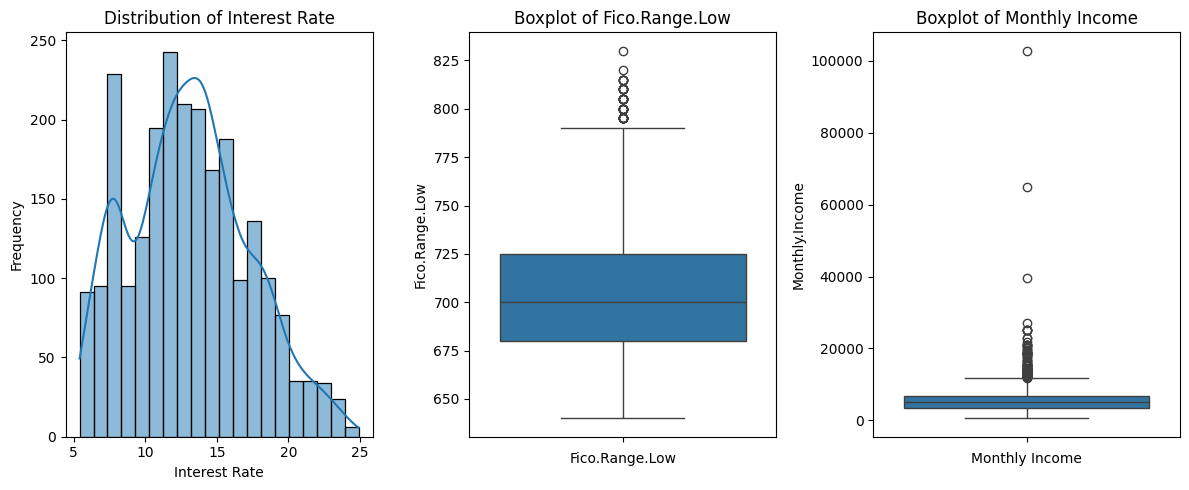

In [9]:
loans_df["Interest.Rate"].value_counts().sort_index(ascending=True)
# loans_df.describe()
import seaborn as sns
import matplotlib.pyplot as plt
# loans_df["Interest.Rate"].plot.hist(bins=20, density=True)
# loans_df["Interest.Rate"].plot.kde()
# plt.title("Distribution of Interest Rate")
# plt.xlabel("Interest Rate")
# plt.ylabel("Frequency")
fig, axes = plt.subplots(1,3, figsize=(12,5))
sns.histplot(loans_df["Interest.Rate"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Interest Rate")
axes[0].set_xlabel("Interest Rate")
axes[0].set_ylabel("Frequency")

sns.boxplot(y="Fico.Range.Low", data=loans_df, ax=axes[1])
axes[1].set_title("Boxplot of Fico.Range.Low")
axes[1].set_xlabel("Fico.Range.Low")

sns.boxplot(y="Monthly.Income", data=loans_df, ax=axes[2])
axes[2].set_title("Boxplot of Monthly Income")
axes[2].set_xlabel("Monthly Income")
plt.tight_layout()
plt.show()

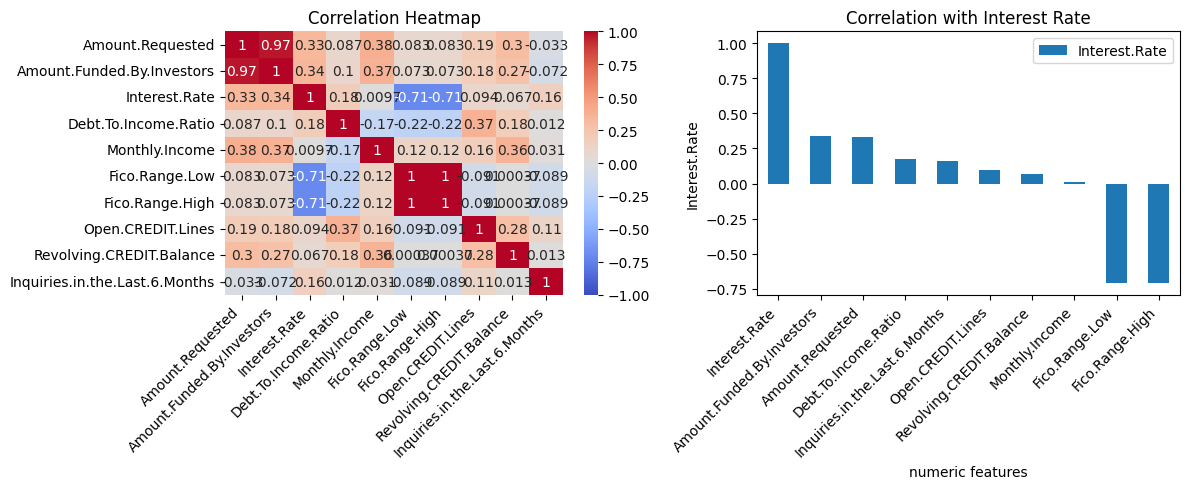

In [10]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
loans_df[cols_numeric].corr()["Interest.Rate"].sort_values(ascending=False)
corrs = loans_df[cols_numeric].corr()
sns.heatmap(data=corrs, vmax=1, vmin=-1, annot=True, cmap="coolwarm" , ax=axes[0])
axes[0].set_title("Correlation Heatmap")
axes[0].set_xticklabels(corrs.columns, rotation=45, ha="right")
axes[0].set_yticklabels(corrs.columns, rotation=0)

corrs_interest = corrs[["Interest.Rate"]].sort_values(by="Interest.Rate", ascending=False)
corrs_interest.plot.bar(ax=axes[1])    
axes[1].set_title("Correlation with Interest Rate")
axes[1].set_xticklabels(corrs_interest.index, rotation=45, ha="right")
axes[1].set_xlabel("numeric features")
axes[1].set_ylabel("Interest.Rate")
plt.tight_layout()
plt.show()


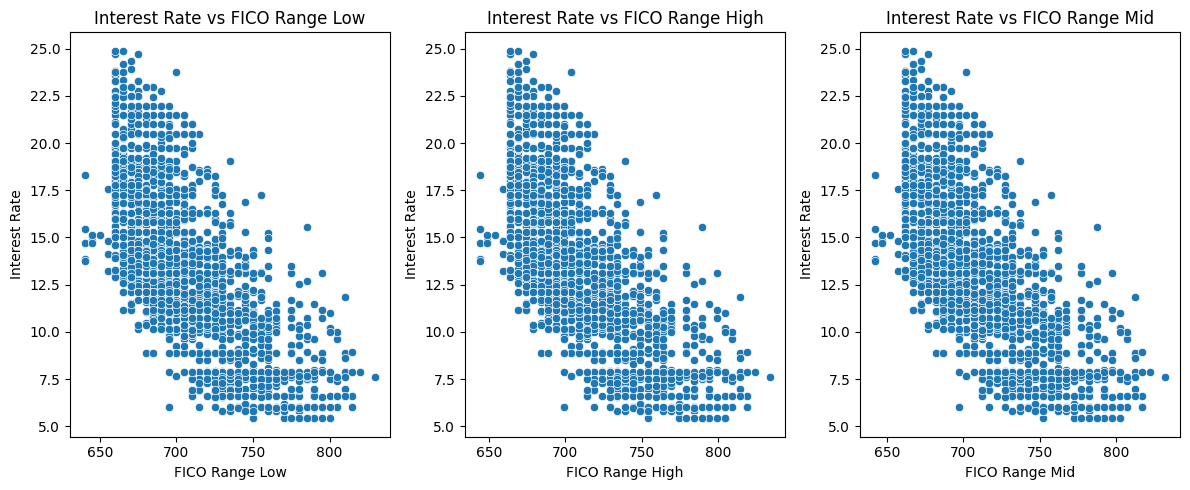

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
sns.scatterplot(x="Fico.Range.Low", y="Interest.Rate", data=loans_df, ax=axes[0])
axes[0].set_title("Interest Rate vs FICO Range Low")
axes[0].set_xlabel("FICO Range Low")
axes[0].set_ylabel("Interest Rate")

sns.scatterplot(x="Fico.Range.High", y="Interest.Rate", data=loans_df, ax=axes[1])
axes[1].set_title("Interest Rate vs FICO Range High")
axes[1].set_xlabel("FICO Range High")
axes[1].set_ylabel("Interest Rate")

loans_df["Fico.Range.Mid"] = (loans_df["Fico.Range.Low"] + loans_df["Fico.Range.High"]) / 2
sns.scatterplot(x="Fico.Range.Mid", y="Interest.Rate", data=loans_df, ax=axes[2])
axes[2].set_title("Interest Rate vs FICO Range Mid")
axes[2].set_xlabel("FICO Range Mid")
axes[2].set_ylabel("Interest Rate")

plt.tight_layout()
plt.show()

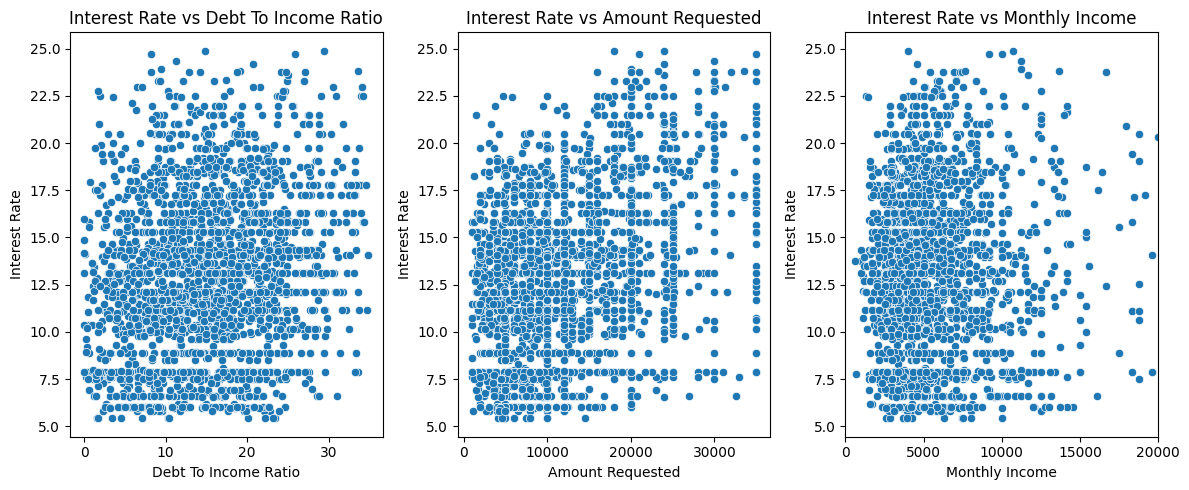

In [12]:
figure,axes = plt.subplots(1, 3, figsize=(12, 5))
sns.scatterplot(x="Debt.To.Income.Ratio", y="Interest.Rate", data=loans_df, ax=axes[0])
axes[0].set_title("Interest Rate vs Debt To Income Ratio")
axes[0].set_xlabel("Debt To Income Ratio")
axes[0].set_ylabel("Interest Rate")

sns.scatterplot(x="Amount.Requested", y="Interest.Rate", data=loans_df, ax=axes[1])
axes[1].set_title("Interest Rate vs Amount Requested")
axes[1].set_xlabel("Amount Requested")
axes[1].set_ylabel("Interest Rate")

sns.scatterplot(x="Monthly.Income", y="Interest.Rate", data=loans_df, ax=axes[2])
axes[2].set_title("Interest Rate vs Monthly Income")
axes[2].set_xlabel("Monthly Income")
axes[2].set_xlim(0, 20000)
axes[2].set_ylabel("Interest Rate")

plt.tight_layout()
plt.show()

/var/folders/gq/wc_79v3d42j0mpv3x1wgp0v80000gn/T/ipykernel_96011/3836749496.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
/var/folders/gq/wc_79v3d42j0mpv3x1wgp0v80000gn/T/ipykernel_96011/3836749496.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha="right")


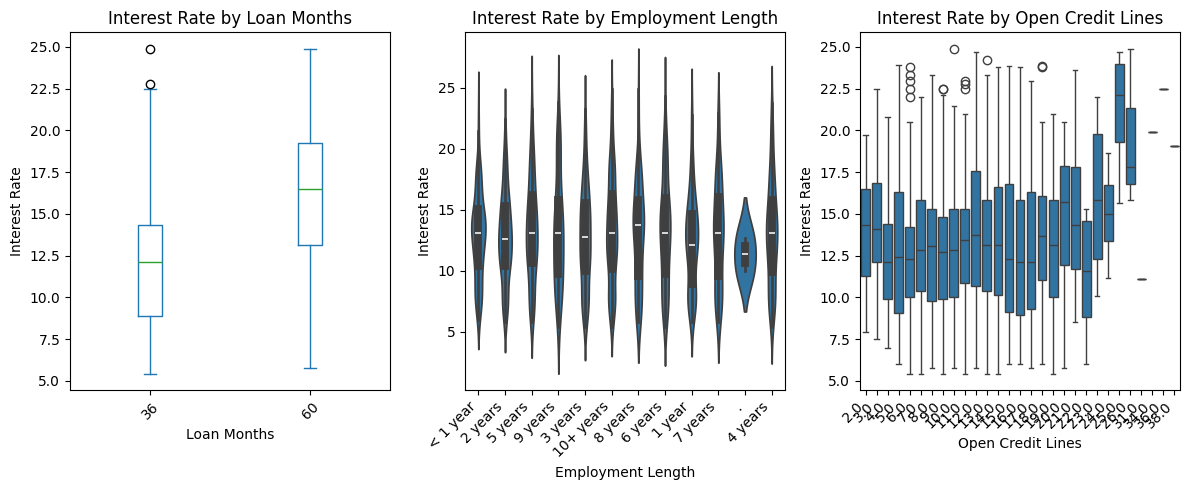

In [13]:
fig,axes = plt.subplots(1, 3, figsize=(12, 5))
# sns.boxplot(x="Loan.Purpose", y="Interest.Rate", data=loans_df, ax=axes[0])
loans_df.plot.box(column="Interest.Rate", by="Loan.Months", ax=axes[0], rot=45)
# axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].set_title("Interest Rate by Loan Months")
axes[0].set_xlabel("Loan Months")
axes[0].set_ylabel("Interest Rate")

sns.violinplot(x="Employment.Length", y="Interest.Rate", data=loans_df, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
axes[1].set_title("Interest Rate by Employment Length")
axes[1].set_xlabel("Employment Length")
axes[1].set_ylabel("Interest Rate")

sns.boxplot(x="Open.CREDIT.Lines", y="Interest.Rate", data=loans_df, ax=axes[2])
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha="right")

axes[2].set_title("Interest Rate by Open Credit Lines")
axes[2].set_xlabel("Open Credit Lines")
axes[2].set_ylabel("Interest Rate")
plt.tight_layout()
plt.show()



/var/folders/gq/wc_79v3d42j0mpv3x1wgp0v80000gn/T/ipykernel_96011/412861564.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
/var/folders/gq/wc_79v3d42j0mpv3x1wgp0v80000gn/T/ipykernel_96011/412861564.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha="right")


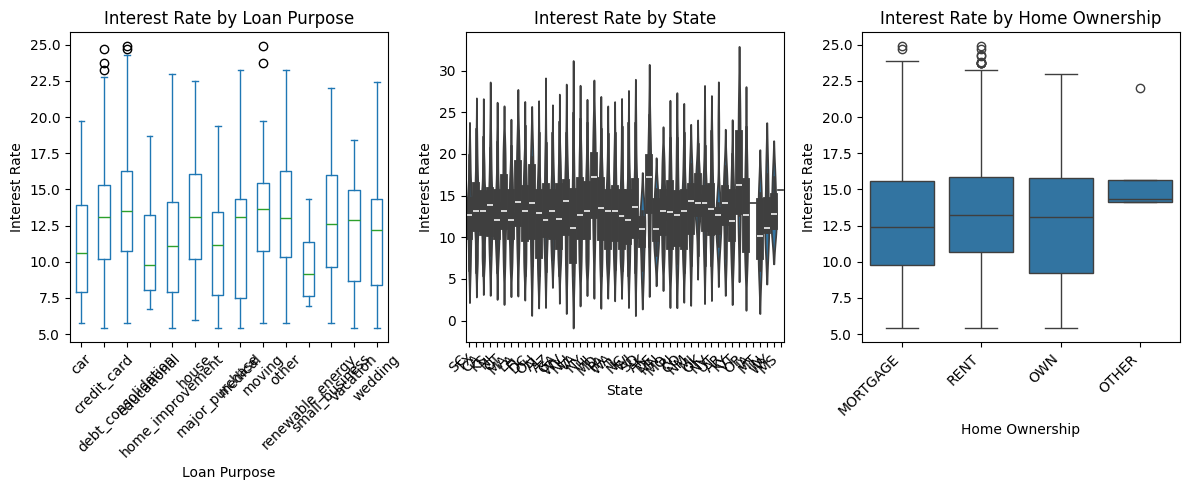

In [14]:

fig,axes = plt.subplots(1, 3, figsize=(12, 5))
# sns.boxplot(x="Loan.Purpose", y="Interest.Rate", data=loans_df, ax=axes[0])
loans_df.plot.box(column="Interest.Rate", by="Loan.Purpose", ax=axes[0], rot=45)
# axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].set_title("Interest Rate by Loan Purpose")
axes[0].set_xlabel("Loan Purpose")
axes[0].set_ylabel("Interest Rate")

sns.violinplot(x="State", y="Interest.Rate", data=loans_df, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
axes[1].set_title("Interest Rate by State")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Interest Rate")

sns.boxplot(x="Home.Ownership", y="Interest.Rate", data=loans_df, ax=axes[2])
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha="right")

axes[2].set_title("Interest Rate by Home Ownership")
axes[2].set_xlabel("Home Ownership")
axes[2].set_ylabel("Interest Rate")
plt.tight_layout()
plt.show()


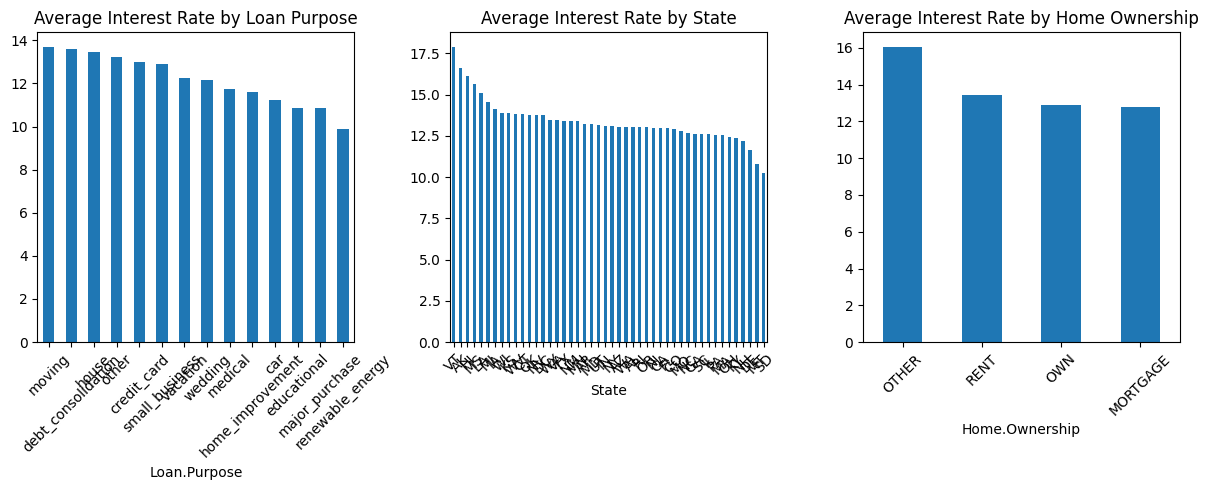

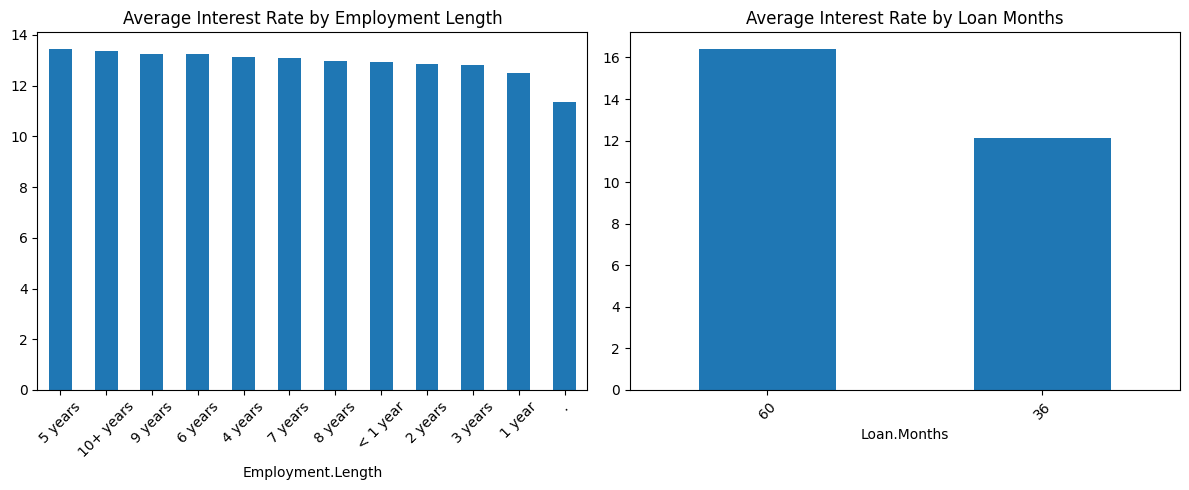

In [ ]:
cols_categorical = [
    "Employment.Length",
    "Loan.Purpose",
    "State",
    "Home.Ownership",
    "Loan.Months",
]
figure, axes = plt.subplots(1, 3, figsize=(12, 5))
purpose_mean = loans_df.groupby("Loan.Purpose")["Interest.Rate"].mean().sort_values(ascending=False)
purpose_mean.plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Interest Rate by Loan Purpose")
axes[0].set_xticklabels(purpose_mean.index, rotation=45)

state_mean = loans_df.groupby("State")["Interest.Rate"].mean().sort_values(ascending=False)
state_mean.plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Interest Rate by State")
axes[1].set_xticklabels(state_mean.index, rotation=45)  

home_ownership_mean = loans_df.groupby("Home.Ownership")["Interest.Rate"].mean().sort_values(ascending=False)
home_ownership_mean.plot(kind="bar", ax=axes[2])            
axes[2].set_title("Average Interest Rate by Home Ownership")
axes[2].set_xticklabels(home_ownership_mean.index, rotation=45) 
print("\n")

plt.tight_layout()
plt.show()

figure, axes = plt.subplots(1, 2, figsize=(12, 5))
employment_length_mean = loans_df.groupby("Employment.Length")["Interest.Rate"].mean().sort_values(ascending=False)
employment_length_mean.plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Interest Rate by Employment Length")
axes[0].set_xticklabels(employment_length_mean.index, rotation=45)      
loan_months_mean = loans_df.groupby("Loan.Months")["Interest.Rate"].mean().sort_values(ascending=False)
loan_months_mean.plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Interest Rate by Loan Months")
axes[1].set_xticklabels(loan_months_mean.index, rotation=45)
plt.tight_layout()
plt.show()      

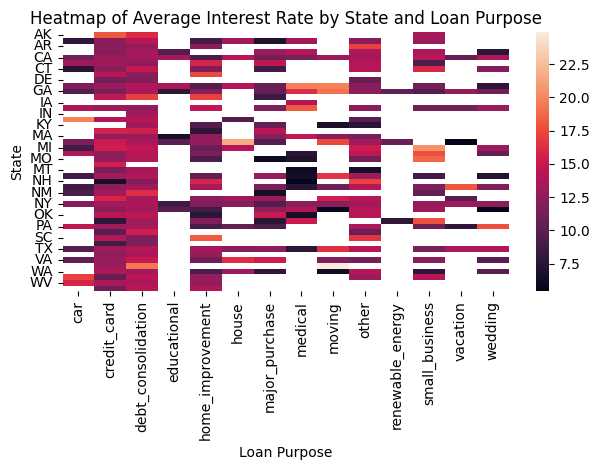

In [26]:
import numpy as np
em_state_interest = loans_df.pivot_table(values="Interest.Rate", index="State", columns="Loan.Purpose", aggfunc="mean").astype(np.float64)

sns.heatmap(em_state_interest , fmt=".2f")
plt.title("Heatmap of Average Interest Rate by State and Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [ ]:
# step 3: 单变量分布
# numberical columns
loans_df["Monthly.Income"].hist(bins=50)
loans_df["Monthly.Income"].describe()

In [ ]:
# categorical columns
loans_df["Loan.Purpose"].value_counts()

In [ ]:
# step 4: 目标变量
# loans_df["Interest.Rate"] = loans_df["Interest.Rate"].str.rstrip("%").astype(float)
loans_df.head(10)


In [ ]:
#step 5: 变量关系
loans_df.plot.scatter(x="Monthly.Income", y="Interest.Rate")
loans_df.plot.scatter(x="FICO.Range", y="Interest.Rate")

In [ ]:
#step 6 : 相关性
import seaborn as sns
sns.heatmap(loans_df.corr(), annot=True, cmap="coolwarm")

In [ ]:
# step 7:异常性
loans_df["Monthly.Income"].sort_values(ascending=False).head(10)
#loans_df.boxplot(column="Monthly.Income", by="Loan.Purpose")